# S6E8 - Predicting Smartphone Addiction
## Score: .96893

## Setup

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("playground-series-s6e8")
TARGET = "addicted_label"

## Load Data

In [15]:
train = pd.read_csv(DATA_DIR / "train.csv", index_col="id")
test = pd.read_csv(DATA_DIR / "test.csv", index_col="id")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", index_col="id")

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
train.head()

train: (691369, 13)
test:  (296302, 12)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
id,,,,,,,,,,,,,
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## Schema and Missingness

In [16]:
features = [c for c in train.columns if c != TARGET]
num_cols = train[features].select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

overview = pd.DataFrame(
    {
        "dtype": train[features].dtypes.astype(str),
        "nunique": train[features].nunique(),
        "train_missing_pct": train[features].isna().mean().mul(100).round(2),
        "test_missing_pct": test[features].isna().mean().mul(100).round(2),
    }
)

print(f"numeric ({len(num_cols)}): {num_cols}")
print(f"categorical ({len(cat_cols)}): {cat_cols}")
overview

numeric (9): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
categorical (3): ['gender', 'stress_level', 'academic_work_impact']


,dtype,nunique,train_missing_pct,test_missing_pct
age,float64,18,4.18,5.78
daily_screen_time_hours,float64,1389,13.86,11.07
social_media_hours,float64,721,19.38,16.00
gaming_hours,float64,401,18.34,20.05
work_study_hours,float64,600,7.45,9.37
sleep_hours,float64,451,6.43,7.58
notifications_per_day,float64,231,9.78,11.55
app_opens_per_day,float64,166,11.67,8.68
weekend_screen_time,float64,1437,16.21,17.11
gender,str,3,4.20,4.80


In [17]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


## Target Balance

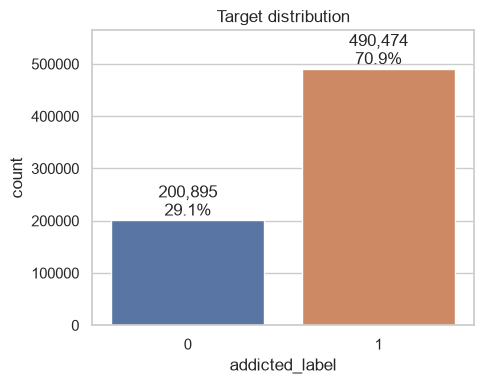

In [18]:
counts = train[TARGET].value_counts().sort_index()
rates = train[TARGET].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str), legend=False, ax=ax)
for i, (n, p) in enumerate(zip(counts.values, rates.values)):
    ax.text(i, n, f"{n:,}\n{p:.1%}", ha="center", va="bottom")
ax.set(xlabel=TARGET, ylabel="count", title="Target distribution")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Numeric Distributions by Target

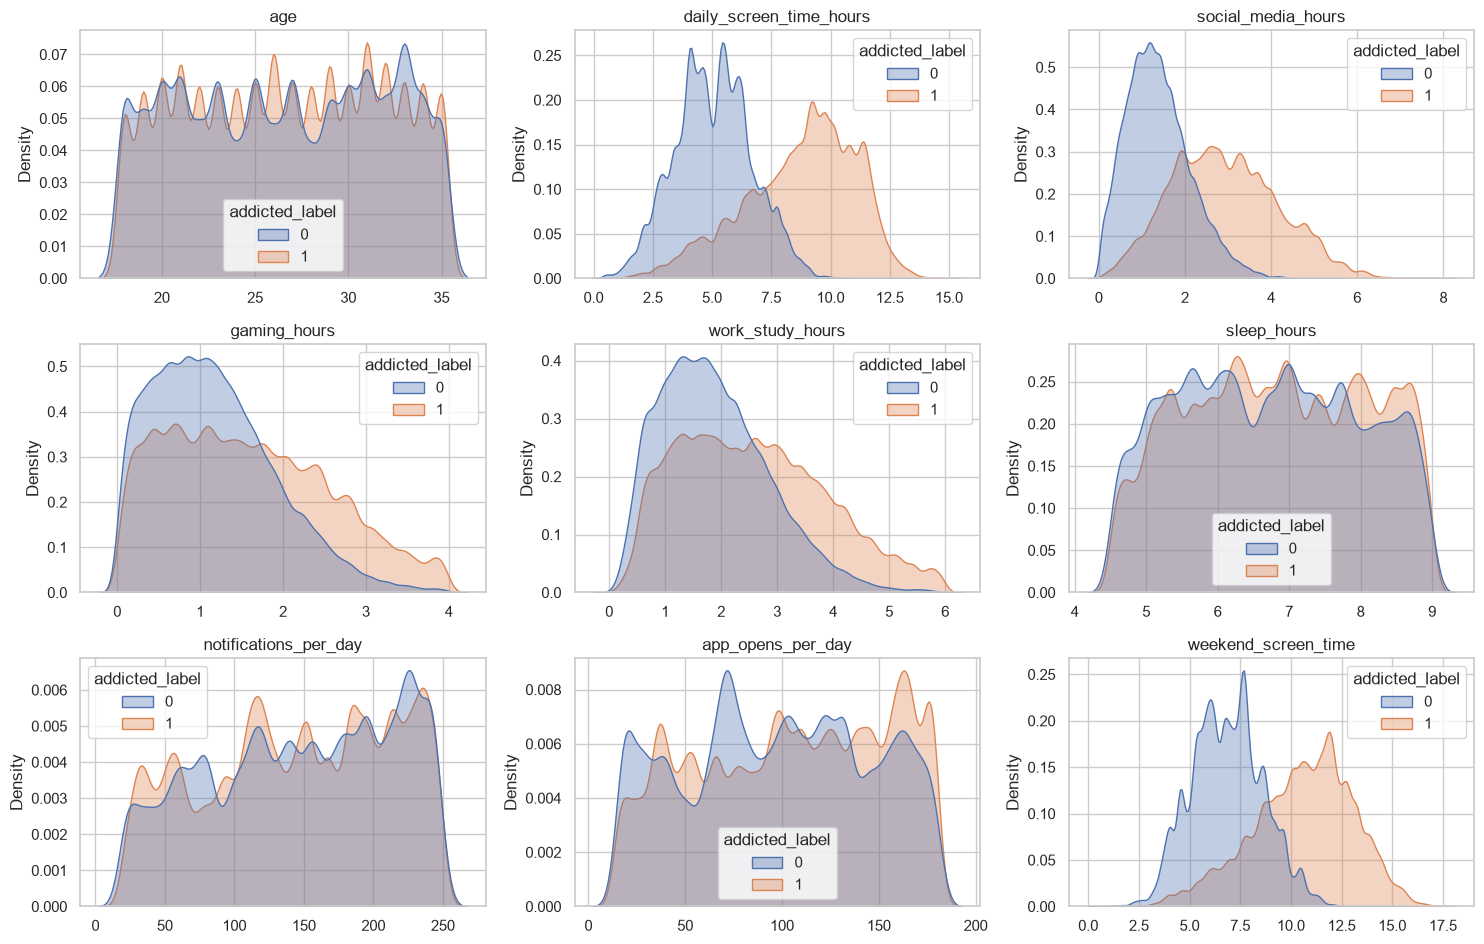

In [19]:
ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))

for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=train, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.35, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes.ravel()[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## Categorical Features vs Target

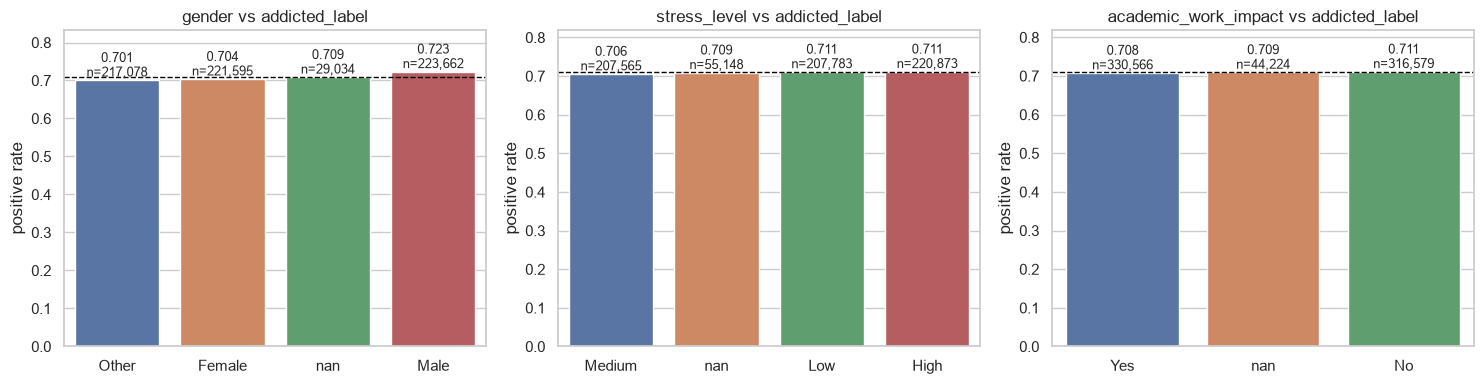

In [20]:
base_rate = train[TARGET].mean()
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(np.atleast_1d(axes), cat_cols):
    stats = train.groupby(col, dropna=False)[TARGET].agg(["mean", "size"]).sort_values("mean")
    labels = [str(i) for i in stats.index]
    sns.barplot(x=labels, y=stats["mean"].values, hue=labels, legend=False, ax=ax)
    ax.axhline(base_rate, ls="--", c="black", lw=1)
    for i, (m, n) in enumerate(zip(stats["mean"].values, stats["size"].values)):
        ax.text(i, m, f"{m:.3f}\nn={n:,}", ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{col} vs {TARGET}", xlabel="", ylabel="positive rate")
    ax.margins(y=0.15)

plt.tight_layout()
plt.show()

## Correlation Matrix

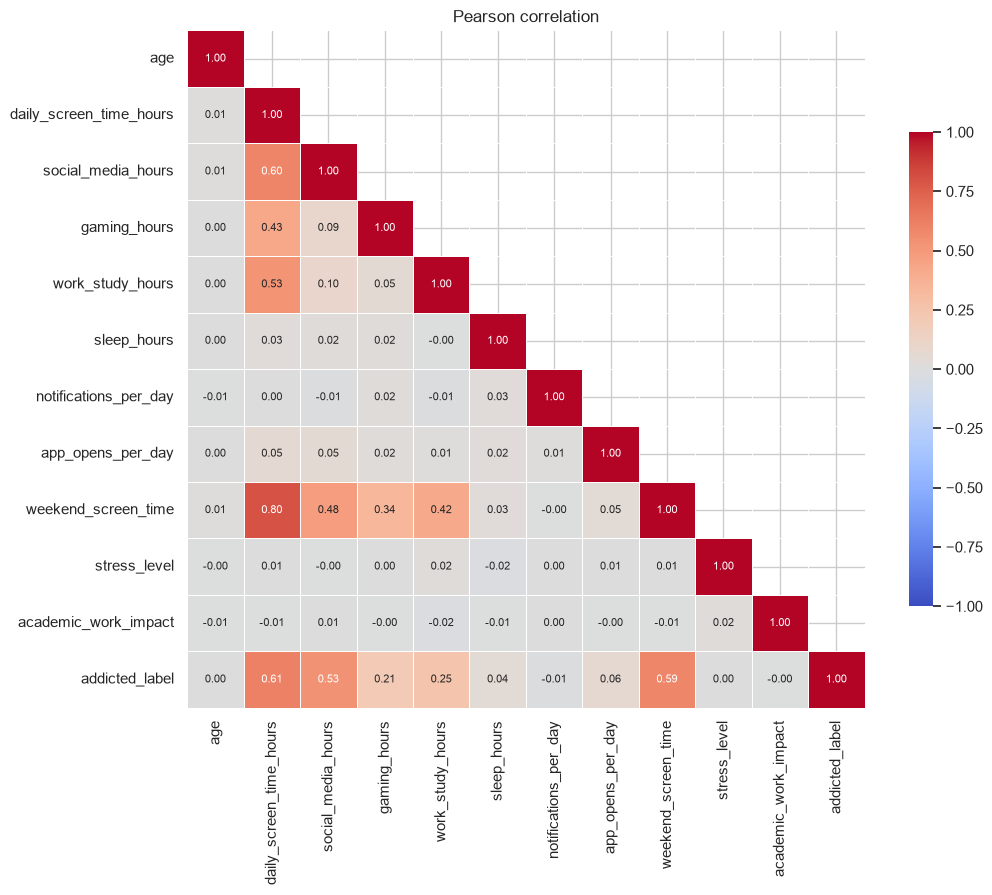

In [21]:
corr_df = train[num_cols].copy()
corr_df["stress_level"] = train["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
corr_df["academic_work_impact"] = train["academic_work_impact"].map({"No": 0, "Yes": 1})
corr_df[TARGET] = train[TARGET]

corr = corr_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Pearson correlation")
plt.tight_layout()
plt.show()

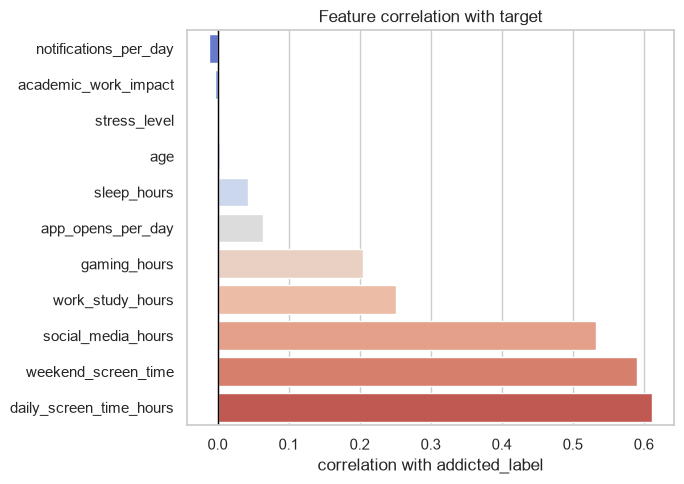

,corr
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
notifications_per_day,-0.011583
age,0.004043
academic_work_impact,-0.003464


In [22]:
target_corr = corr[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, legend=False, palette="coolwarm", ax=ax)
ax.axvline(0, c="black", lw=1)
ax.set(xlabel=f"correlation with {TARGET}", ylabel="", title="Feature correlation with target")
plt.tight_layout()
plt.show()

target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).to_frame("corr")

## Feature Prep

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import QuantileTransformer

DIGIT_COLS = [
    "age",
    "daily_screen_time_hours",
    "weekend_screen_time",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
]


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in features:
        out[f"{col}_isna"] = out[col].isna().astype(np.int8)

    out["missing_count"] = out[features].isna().sum(axis=1).astype(np.int8)
    out["missing_frac"] = out["missing_count"] / len(features)

    daily = out["daily_screen_time_hours"]
    weekend = out["weekend_screen_time"]
    social = out["social_media_hours"]
    gaming = out["gaming_hours"]
    work = out["work_study_hours"]
    sleep = out["sleep_hours"]
    notifs = out["notifications_per_day"]
    opens = out["app_opens_per_day"]

    out["weekend_daily_ratio"] = weekend / daily
    out["weekend_daily_diff"] = weekend - daily
    out["social_share"] = social / daily
    out["gaming_share"] = gaming / daily
    out["work_share"] = work / daily
    out["leisure_hours"] = social + gaming
    out["active_hours"] = social + gaming + work
    out["leisure_share"] = out["leisure_hours"] / daily
    out["screen_sleep_ratio"] = daily / sleep
    out["weekend_sleep_ratio"] = weekend / sleep
    out["notif_per_open"] = notifs / opens
    out["opens_per_notif"] = opens / notifs
    out["screen_per_open"] = daily / opens
    out["social_gaming_ratio"] = social / gaming
    out["work_leisure_ratio"] = work / out["leisure_hours"]

    for col in DIGIT_COLS:
        s = out[col]
        out[f"{col}_int"] = np.floor(s).astype("Int64").astype("string")
        frac = np.floor(((s - np.floor(s)) * 100).round(6)).astype("Int64")
        out[f"{col}_frac2"] = frac.astype("string")
        out[f"{col}_r1"] = s.round(1).astype("string")

    return out.replace([np.inf, -np.inf], np.nan)


def add_regime_flags(df: pd.DataFrame, cuts: dict, prefix: str = "") -> pd.DataFrame:
    out = df.copy()
    daily = out["daily_screen_time_hours"]
    weekend = out["weekend_screen_time"]
    social = out["social_media_hours"]
    gaming = out["gaming_hours"]
    work = out["work_study_hours"]
    sleep = out["sleep_hours"]
    notifs = out["notifications_per_day"]
    opens = out["app_opens_per_day"]
    leisure = social + gaming
    p = prefix

    out[f"{p}reg_high_screen_low_sleep"] = (
        (daily >= cuts["daily_hi"]) & (sleep <= cuts["sleep_lo"])
    ).astype(np.int8)
    out[f"{p}reg_high_weekend_low_sleep"] = (
        (weekend >= cuts["weekend_hi"]) & (sleep <= cuts["sleep_lo"])
    ).astype(np.int8)
    out[f"{p}reg_high_notif_high_open"] = (
        (notifs >= cuts["notifs_hi"]) & (opens >= cuts["opens_hi"])
    ).astype(np.int8)
    out[f"{p}reg_social_heavy"] = (
        (social >= cuts["social_hi"]) & (social >= gaming) & (social >= work)
    ).astype(np.int8)
    out[f"{p}reg_gaming_heavy"] = (
        (gaming >= cuts["gaming_hi"]) & (gaming >= social)
    ).astype(np.int8)
    out[f"{p}reg_work_dominant"] = (
        (work >= cuts["work_hi"]) & (work >= leisure)
    ).astype(np.int8)
    out[f"{p}reg_weekend_binge"] = (
        (weekend >= cuts["weekend_hi"]) & (weekend >= daily)
    ).astype(np.int8)
    out[f"{p}reg_always_on"] = (
        (notifs >= cuts["notifs_hi"]) & (daily >= cuts["daily_hi"]) & (opens >= cuts["opens_hi"])
    ).astype(np.int8)
    out[f"{p}reg_low_engage"] = (
        (notifs <= cuts["notifs_lo"]) & (opens <= cuts["opens_lo"]) & (daily <= cuts["daily_lo"])
    ).astype(np.int8)
    out[f"{p}reg_sleep_deprived_leisure"] = (
        (sleep <= cuts["sleep_lo"]) & (leisure >= cuts["leisure_hi"])
    ).astype(np.int8)

    out[f"{p}regime_count"] = (
        out[[c for c in out.columns if c.startswith(f"{p}reg_")]].sum(axis=1).astype(np.int8)
    )

    out[f"{p}str_daily_hi"] = (daily - cuts["daily_hi"]) / (cuts["daily_hi"] + 1e-6)
    out[f"{p}str_daily_lo"] = (cuts["daily_lo"] - daily) / (cuts["daily_lo"] + 1e-6)
    out[f"{p}str_weekend_hi"] = (weekend - cuts["weekend_hi"]) / (cuts["weekend_hi"] + 1e-6)
    out[f"{p}str_sleep_lo"] = (cuts["sleep_lo"] - sleep) / (cuts["sleep_lo"] + 1e-6)
    out[f"{p}str_notifs_hi"] = (notifs - cuts["notifs_hi"]) / (cuts["notifs_hi"] + 1e-6)
    out[f"{p}str_opens_hi"] = (opens - cuts["opens_hi"]) / (cuts["opens_hi"] + 1e-6)
    out[f"{p}str_social_hi"] = (social - cuts["social_hi"]) / (cuts["social_hi"] + 1e-6)
    out[f"{p}str_gaming_hi"] = (gaming - cuts["gaming_hi"]) / (cuts["gaming_hi"] + 1e-6)
    out[f"{p}str_work_hi"] = (work - cuts["work_hi"]) / (cuts["work_hi"] + 1e-6)
    out[f"{p}str_leisure_hi"] = (leisure - cuts["leisure_hi"]) / (cuts["leisure_hi"] + 1e-6)

    out[f"{p}str_screen_sleep"] = out[f"{p}str_daily_hi"] + out[f"{p}str_sleep_lo"]
    out[f"{p}str_weekend_sleep"] = out[f"{p}str_weekend_hi"] + out[f"{p}str_sleep_lo"]
    out[f"{p}str_notif_open"] = out[f"{p}str_notifs_hi"] + out[f"{p}str_opens_hi"]
    out[f"{p}str_always_on"] = out[f"{p}str_notifs_hi"] + out[f"{p}str_daily_hi"] + out[f"{p}str_opens_hi"]
    out[f"{p}str_sleep_leisure"] = out[f"{p}str_sleep_lo"] + out[f"{p}str_leisure_hi"]
    out[f"{p}str_weekend_over_daily"] = (weekend - daily) / (daily.abs() + 1e-6)

    return out.replace([np.inf, -np.inf], np.nan)


def make_cuts(frame: pd.DataFrame) -> dict:
    return {
        "daily_hi": float(frame["daily_screen_time_hours"].quantile(0.75)),
        "daily_lo": float(frame["daily_screen_time_hours"].quantile(0.25)),
        "weekend_hi": float(frame["weekend_screen_time"].quantile(0.75)),
        "sleep_lo": float(frame["sleep_hours"].quantile(0.25)),
        "notifs_hi": float(frame["notifications_per_day"].quantile(0.75)),
        "notifs_lo": float(frame["notifications_per_day"].quantile(0.25)),
        "opens_hi": float(frame["app_opens_per_day"].quantile(0.75)),
        "opens_lo": float(frame["app_opens_per_day"].quantile(0.25)),
        "social_hi": float(frame["social_media_hours"].quantile(0.75)),
        "gaming_hi": float(frame["gaming_hours"].quantile(0.75)),
        "work_hi": float(frame["work_study_hours"].quantile(0.75)),
        "leisure_hi": float((frame["social_media_hours"] + frame["gaming_hours"]).quantile(0.75)),
    }


y = train[TARGET].astype(int)
X = add_features(train[features])
X_test = add_features(test[features])

cuts = make_cuts(X)
X = add_regime_flags(X, cuts)
X_test = add_regime_flags(X_test, cuts)

orig = pd.read_csv(Path("external/original.csv"))
orig_cuts = make_cuts(orig)
X = add_regime_flags(X, orig_cuts, prefix="orig_")
X_test = add_regime_flags(X_test, orig_cuts, prefix="orig_")

digit_cats = [f"{c}_{s}" for c in DIGIT_COLS for s in ("int", "frac2", "r1")]
all_cat_cols = list(dict.fromkeys(cat_cols + digit_cats))

for col in all_cat_cols:
    cats = sorted({*(X[col].dropna().astype(str)), *(X_test[col].dropna().astype(str)), "Missing"})
    X[col] = pd.Categorical(X[col].astype("string").fillna("Missing"), categories=cats)
    X_test[col] = pd.Categorical(X_test[col].astype("string").fillna("Missing"), categories=cats)

# Small lookup-rate family on digit signatures only
lookup_specs = {
    "lookup_daily_int": "daily_screen_time_hours_int",
    "lookup_weekend_int": "weekend_screen_time_int",
    "lookup_sleep_int": "sleep_hours_int",
    "lookup_notif_open": X["notifications_per_day_int"].astype(str) + "_" + X["app_opens_per_day_int"].astype(str),
    "lookup_social_game": X["social_media_hours_int"].astype(str) + "_" + X["gaming_hours_int"].astype(str),
}
lookup_specs_test = {
    "lookup_daily_int": "daily_screen_time_hours_int",
    "lookup_weekend_int": "weekend_screen_time_int",
    "lookup_sleep_int": "sleep_hours_int",
    "lookup_notif_open": X_test["notifications_per_day_int"].astype(str) + "_" + X_test["app_opens_per_day_int"].astype(str),
    "lookup_social_game": X_test["social_media_hours_int"].astype(str) + "_" + X_test["gaming_hours_int"].astype(str),
}

cv_lookup = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
global_mean = float(y.mean())
for feat_name, train_key in lookup_specs.items():
    train_series = X[train_key].astype(str) if isinstance(train_key, str) else train_key
    test_key = lookup_specs_test[feat_name]
    test_series = X_test[test_key].astype(str) if isinstance(test_key, str) else test_key
    oof_vals = np.full(len(X), global_mean, dtype=np.float64)
    for tr_idx, va_idx in cv_lookup.split(X, y):
        key_tr = train_series.iloc[tr_idx]
        means = y.iloc[tr_idx].groupby(key_tr, observed=False).mean()
        oof_vals[va_idx] = train_series.iloc[va_idx].map(means).fillna(global_mean).to_numpy()
    X[feat_name] = oof_vals
    full_means = y.groupby(train_series, observed=False).mean()
    X_test[feat_name] = test_series.map(full_means).fillna(global_mean).astype(np.float64)

# Digits-only member view: raw numerics + missing + digit cats, no regime/orig regime and no RankGauss
digit_view_cols = []
for c in features:
    digit_view_cols.append(c)
    digit_view_cols.append(f"{c}_isna")
digit_view_cols += ["missing_count", "missing_frac"] + digit_cats + [
    "lookup_daily_int",
    "lookup_weekend_int",
    "lookup_sleep_int",
    "lookup_notif_open",
    "lookup_social_game",
]
digit_view_cols = list(dict.fromkeys(digit_view_cols))
X_digits = X[digit_view_cols].copy()
X_digits_test = X_test[digit_view_cols].copy()

num_cols_x = [
    c
    for c in X.columns
    if c not in all_cat_cols
    and not str(c).endswith("_isna")
    and c != "missing_count"
    and not str(c).startswith("reg_")
    and not str(c).startswith("orig_reg_")
    and c not in ("regime_count", "orig_regime_count")
]
qt = QuantileTransformer(
    n_quantiles=min(1000, len(X)),
    output_distribution="normal",
    subsample=min(200_000, len(X)),
    random_state=42,
)
med = X[num_cols_x].median()
X_num = X[num_cols_x].fillna(med)
X_test_num = X_test[num_cols_x].fillna(med)
X_q = pd.DataFrame(qt.fit_transform(X_num), index=X.index, columns=num_cols_x)
X_test_q = pd.DataFrame(qt.transform(X_test_num), index=X_test.index, columns=num_cols_x)
X_q[X[num_cols_x].isna()] = np.nan
X_test_q[X_test[num_cols_x].isna()] = np.nan
X[num_cols_x] = X_q
X_test[num_cols_x] = X_test_q

print(X.shape, X_test.shape, X_digits.shape, y.mean().round(4), "cats", len(all_cat_cols))
X.head()


(691369, 127) (296302, 127) (691369, 58) 0.7094 cats 30


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_isna,daily_screen_time_hours_isna,social_media_hours_isna,gaming_hours_isna,work_study_hours_isna,sleep_hours_isna,notifications_per_day_isna,app_opens_per_day_isna,weekend_screen_time_isna,gender_isna,stress_level_isna,academic_work_impact_isna,missing_count,missing_frac,weekend_daily_ratio,weekend_daily_diff,social_share,gaming_share,work_share,leisure_hours,active_hours,leisure_share,screen_sleep_ratio,weekend_sleep_ratio,notif_per_open,opens_per_notif,screen_per_open,social_gaming_ratio,work_leisure_ratio,age_int,age_frac2,age_r1,daily_screen_time_hours_int,daily_screen_time_hours_frac2,daily_screen_time_hours_r1,weekend_screen_time_int,weekend_screen_time_frac2,weekend_screen_time_r1,social_media_hours_int,social_media_hours_frac2,social_media_hours_r1,gaming_hours_int,gaming_hours_frac2,gaming_hours_r1,work_study_hours_int,work_study_hours_frac2,work_study_hours_r1,sleep_hours_int,sleep_hours_frac2,sleep_hours_r1,notifications_per_day_int,notifications_per_day_frac2,notifications_per_day_r1,app_opens_per_day_int,app_opens_per_day_frac2,app_opens_per_day_r1,reg_high_screen_low_sleep,reg_high_weekend_low_sleep,reg_high_notif_high_open,reg_social_heavy,reg_gaming_heavy,reg_work_dominant,reg_weekend_binge,reg_always_on,reg_low_engage,reg_sleep_deprived_leisure,regime_count,str_daily_hi,str_daily_lo,str_weekend_hi,str_sleep_lo,str_notifs_hi,str_opens_hi,str_social_hi,str_gaming_hi,str_work_hi,str_leisure_hi,str_screen_sleep,str_weekend_sleep,str_notif_open,str_always_on,str_sleep_leisure,str_weekend_over_daily,orig_reg_high_screen_low_sleep,orig_reg_high_weekend_low_sleep,orig_reg_high_notif_high_open,orig_reg_social_heavy,orig_reg_gaming_heavy,orig_reg_work_dominant,orig_reg_weekend_binge,orig_reg_always_on,orig_reg_low_engage,orig_reg_sleep_deprived_leisure,orig_regime_count,orig_str_daily_hi,orig_str_daily_lo,orig_str_weekend_hi,orig_str_sleep_lo,orig_str_notifs_hi,orig_str_opens_hi,orig_str_social_hi,orig_str_gaming_hi,orig_str_work_hi,orig_str_leisure_hi,orig_str_screen_sleep,orig_str_weekend_sleep,orig_str_notif_open,orig_str_always_on,orig_str_sleep_leisure,orig_str_weekend_over_daily,lookup_daily_int,lookup_weekend_int,lookup_sleep_int,lookup_notif_open,lookup_social_game
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.421111,NaN,-0.548158,0.440383,-0.147316,0.471004,-0.397918,-1.207532,-0.437620,Male,Medium,No,0,1,0,0,0,0,0,0,0,0,0,0,1,0.051460,NaN,NaN,NaN,NaN,NaN,-0.549616,-0.661162,NaN,NaN,-0.681622,1.090831,-1.090836,NaN,-0.782134,0.464064,24,0,24.0,Missing,Missing,Missing,8,63,8.6,1,83,1.8,1,59,1.6,2,11,2.1,7,46,7.5,122,0,122.0,38,0,38.0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,-0.437620,-0.471004,-0.397918,-1.207532,-0.548158,0.440383,-0.147316,-0.549616,NaN,-0.758079,-1.254978,NaN,-0.832152,NaN,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,-0.437620,-0.471004,-0.397918,-1.207532,-0.548158,0.440383,-0.147316,-0.549616,NaN,-0.759176,-1.244846,NaN,-0.865263,NaN,-0.317650,-0.459820,-0.180377,5.199338,-1.301191
1,-1.453280,-0.633317,-1.159515,NaN,0.622621,0.999986,-0.939747,-1.968165,NaN,Female,Medium,No,0,0,0,1,0,0,0,0,1,0,0,0,2,0.639462,NaN,NaN,-1.224954,NaN,1.499102,NaN,NaN,NaN,-0.990737,NaN,1.292465,-1.292465,1.773668,NaN,NaN,19,0,19.0,5,97,6.0,Missing,Missing,Missing,1,8,1.1,Missing,Missing,Missing,3,3,3.0,8,22,8.2,76,0,76.0,19,0,19.0,0,0,0,0,0,0,0,0,0,0,0,-0.633317,0.633317,NaN,-0.999986,-0.939747,-1.968165,-1.159515,NaN,0.622621,NaN,-1.256696,NaN,-1.978991,-2.075439,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,-0.633317,0.633317,NaN,-0.999986,-0.939747,-1.968165,-1.159515,NaN,0.622621,NaN,-1.263220,NaN,-1.972592,-2.077398,NaN,NaN,-0.899534,-0.295296,1.057485,-1.161976,-0.583496
2,-5.199338,-0.914679,NaN,NaN,NaN,-0.404717,-0.279606,-0.814401,-0.763030,Female,Low,Yes,0,0,1,1,

## Model

In [24]:
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
SEEDS = [42, 7, 21]
BEST_SPW = 0.75
CB_SEED = 42
T0 = time.time()


def elapsed_min():
    return (time.time() - T0) / 60.0


mono_up = {
    "daily_screen_time_hours",
    "weekend_screen_time",
    "notifications_per_day",
    "app_opens_per_day",
    "social_media_hours",
    "gaming_hours",
    "screen_sleep_ratio",
    "weekend_sleep_ratio",
    "str_daily_hi",
    "str_sleep_lo",
    "orig_str_daily_hi",
    "orig_str_sleep_lo",
}
mono_down = {"sleep_hours"}


def build_monotone(frame):
    return [1 if c in mono_up else (-1 if c in mono_down else 0) for c in frame.columns]


shared = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 4000,
    "max_bin": 255,
    "n_jobs": -1,
    "verbose": -1,
}

configs = {
    "tuned": {
        **shared,
        "learning_rate": 0.05374472845232343,
        "num_leaves": 214,
        "max_depth": 5,
        "min_child_samples": 109,
        "subsample": 0.9625632338704708,
        "colsample_bytree": 0.6274746430860334,
        "reg_alpha": 5.851350659914564,
        "reg_lambda": 1.5699494182020153,
        "min_split_gain": 0.06477603176535501,
        "scale_pos_weight": BEST_SPW,
    },
    "shallow": {
        **shared,
        "learning_rate": 0.07,
        "num_leaves": 31,
        "max_depth": 4,
        "min_child_samples": 80,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.0,
        "reg_lambda": 3.0,
        "min_split_gain": 0.0,
    },
    "deep": {
        **shared,
        "learning_rate": 0.03,
        "num_leaves": 127,
        "max_depth": 8,
        "min_child_samples": 40,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "min_split_gain": 0.0,
    },
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
oof_models = []
test_models = []
model_names = []
importances = pd.DataFrame(index=X.columns)


def run_lgbm_member(name, base_params, frame_train, frame_test, monotone=None, track_importance=False):
    oof_cfg = np.zeros(len(frame_train))
    test_cfg = np.zeros(len(frame_test))
    for seed in SEEDS:
        params = {
            **base_params,
            "random_state": seed,
            "bagging_seed": seed,
            "feature_fraction_seed": seed,
        }
        if monotone is not None:
            params["monotone_constraints"] = monotone
        oof_seed = np.zeros(len(frame_train))
        test_seed = np.zeros(len(frame_test))
        fold_scores = []
        col = f"{name}_{seed}"
        if track_importance:
            importances[col] = 0.0

        for fold, (tr_idx, va_idx) in enumerate(skf.split(frame_train, y), start=1):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                frame_train.iloc[tr_idx],
                y.iloc[tr_idx],
                eval_X=frame_train.iloc[va_idx],
                eval_y=y.iloc[va_idx],
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            oof_seed[va_idx] = model.predict_proba(frame_train.iloc[va_idx])[:, 1]
            test_seed += model.predict_proba(frame_test)[:, 1] / N_SPLITS
            if track_importance:
                importances[col] += model.feature_importances_ / N_SPLITS
            fold_scores.append(roc_auc_score(y.iloc[va_idx], oof_seed[va_idx]))

        seed_auc = roc_auc_score(y, oof_seed)
        print(f"{name} seed {seed}: {seed_auc:.5f}  mean={np.mean(fold_scores):.5f}  elapsed={elapsed_min():.1f}m")
        oof_cfg += oof_seed / len(SEEDS)
        test_cfg += test_seed / len(SEEDS)

    cfg_auc = roc_auc_score(y, oof_cfg)
    print(f"{name} oof: {cfg_auc:.5f}")
    oof_models.append(oof_cfg)
    test_models.append(test_cfg)
    model_names.append(name)


full_mono = build_monotone(X)
run_lgbm_member("tuned", configs["tuned"], X, X_test, monotone=full_mono, track_importance=True)
run_lgbm_member("shallow", configs["shallow"], X, X_test, track_importance=True)
run_lgbm_member("deep", configs["deep"], X, X_test, track_importance=True)

digit_shared = {
    **shared,
    "learning_rate": 0.05,
    "num_leaves": 127,
    "max_depth": 5,
    "min_child_samples": 80,
    "subsample": 0.95,
    "colsample_bytree": 0.7,
    "reg_alpha": 3.0,
    "reg_lambda": 2.0,
    "min_split_gain": 0.02,
    "scale_pos_weight": BEST_SPW,
}
digit_mono = build_monotone(X_digits)
run_lgbm_member("digits", digit_shared, X_digits, X_digits_test, monotone=digit_mono)

print(f"catboost start  elapsed={elapsed_min():.1f}m")
cb_cat = [c for c in X.columns if str(X[c].dtype.name) == "category"]
cb_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 2000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 6.0,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "random_seed": CB_SEED,
    "early_stopping_rounds": 100,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
}

oof_cb = np.zeros(len(X))
test_cb = np.zeros(len(X_test))
fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    print(f"catboost fold {fold} start  elapsed={elapsed_min():.1f}m")
    cb = CatBoostClassifier(**cb_params)
    cb.fit(
        X.iloc[tr_idx],
        y.iloc[tr_idx],
        eval_set=(X.iloc[va_idx], y.iloc[va_idx]),
        cat_features=cb_cat,
        use_best_model=True,
    )
    oof_cb[va_idx] = cb.predict_proba(X.iloc[va_idx])[:, 1]
    test_cb += cb.predict_proba(X_test)[:, 1] / N_SPLITS
    fold_auc = roc_auc_score(y.iloc[va_idx], oof_cb[va_idx])
    fold_scores.append(fold_auc)
    print(f"catboost fold {fold}: {fold_auc:.5f}")

print(f"catboost oof: {roc_auc_score(y, oof_cb):.5f}  mean={np.mean(fold_scores):.5f}")
oof_models.append(oof_cb)
test_models.append(test_cb)
model_names.append("catboost")

# Optional NN member: only runs when CUDA is available
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    use_cuda = torch.cuda.is_available()
except Exception:
    use_cuda = False

if use_cuda:
    print(f"nn start  elapsed={elapsed_min():.1f}m")
    device = torch.device("cuda")
    nn_frame = X.copy()
    nn_test_frame = X_test.copy()
    for col in nn_frame.columns:
        if str(nn_frame[col].dtype.name) == "category":
            nn_frame[col] = nn_frame[col].cat.codes.astype(np.int32)
            nn_test_frame[col] = nn_test_frame[col].cat.codes.astype(np.int32)
    med = nn_frame.median(numeric_only=True)
    nn_frame = nn_frame.fillna(med).astype(np.float32)
    nn_test_frame = nn_test_frame.fillna(med).astype(np.float32)

    x_all = torch.tensor(nn_frame.to_numpy(), dtype=torch.float32)
    x_test_all = torch.tensor(nn_test_frame.to_numpy(), dtype=torch.float32)
    y_all = torch.tensor(y.to_numpy(), dtype=torch.float32)

    class MLP(nn.Module):
        def __init__(self, n_in):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(128, 1),
            )

        def forward(self, x):
            return self.net(x).squeeze(1)

    skf_nn = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    oof_nn = np.zeros(len(X))
    test_nn = np.zeros(len(X_test))
    for fold, (tr_idx, va_idx) in enumerate(skf_nn.split(nn_frame, y), start=1):
        print(f"nn fold {fold} start  elapsed={elapsed_min():.1f}m")
        model = MLP(x_all.shape[1]).to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn = nn.BCEWithLogitsLoss()
        ds = TensorDataset(x_all[tr_idx], y_all[tr_idx])
        dl = DataLoader(ds, batch_size=8192, shuffle=True)
        best_auc = -1.0
        best_state = None
        patience = 0
        x_va = x_all[va_idx].to(device)
        y_va = y.iloc[va_idx].to_numpy()
        for epoch in range(8):
            model.train()
            for xb, yb in dl:
                xb = xb.to(device)
                yb = yb.to(device)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                va_pred = torch.sigmoid(model(x_va)).cpu().numpy()
            auc = roc_auc_score(y_va, va_pred)
            if auc > best_auc:
                best_auc = auc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= 2:
                    break
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            oof_nn[va_idx] = torch.sigmoid(model(x_all[va_idx].to(device))).cpu().numpy()
            test_nn += torch.sigmoid(model(x_test_all.to(device))).cpu().numpy() / 3
        print(f"nn fold {fold}: {best_auc:.5f}")
    print(f"nn oof: {roc_auc_score(y, oof_nn):.5f}")
    oof_models.append(oof_nn)
    test_models.append(test_nn)
    model_names.append("nn")
else:
    print("nn skipped: CUDA not available")

oof_mat = np.column_stack(oof_models)
test_mat = np.column_stack(test_models)


def neg_auc(weights):
    weights = np.clip(weights, 0, None)
    if weights.sum() <= 0:
        return 0.0
    weights = weights / weights.sum()
    return float(-roc_auc_score(y, oof_mat @ weights))


opt = minimize(neg_auc, x0=np.ones(len(model_names)) / len(model_names), method="Nelder-Mead")
weights = np.clip(opt.x, 0, None)
weights = weights / weights.sum()

oof = oof_mat @ weights
test_preds = test_mat @ weights
oof_score = roc_auc_score(y, oof)
print("blend weights:", list(zip(model_names, np.round(weights, 4))))
print(f"blend oof: {oof_score:.5f}")
print(f"elapsed min: {elapsed_min():.1f}")


tuned seed 42: 0.96599  mean=0.96600  elapsed=2.4m
tuned seed 7: 0.96608  mean=0.96608  elapsed=5.0m
tuned seed 21: 0.96610  mean=0.96611  elapsed=7.6m
tuned oof: 0.96642
shallow seed 42: 0.96613  mean=0.96613  elapsed=9.9m
shallow seed 7: 0.96616  mean=0.96616  elapsed=12.2m
shallow seed 21: 0.96611  mean=0.96611  elapsed=14.5m
shallow oof: 0.96648
deep seed 42: 0.96581  mean=0.96581  elapsed=18.3m
deep seed 7: 0.96586  mean=0.96587  elapsed=22.2m
deep seed 21: 0.96578  mean=0.96583  elapsed=26.6m
deep oof: 0.96613
digits seed 42: 0.96459  mean=0.96460  elapsed=28.9m
digits seed 7: 0.96461  mean=0.96461  elapsed=31.1m
digits seed 21: 0.96454  mean=0.96455  elapsed=33.3m
digits oof: 0.96500
catboost start  elapsed=33.3m
catboost fold 1 start  elapsed=33.3m
catboost fold 1: 0.96809
catboost fold 2 start  elapsed=51.8m
catboost fold 2: 0.96910
catboost fold 3 start  elapsed=70.1m
catboost fold 3: 0.96910
catboost fold 4 start  elapsed=88.7m
catboost fold 4: 0.96924
catboost fold 5 start 

## Feature Importance

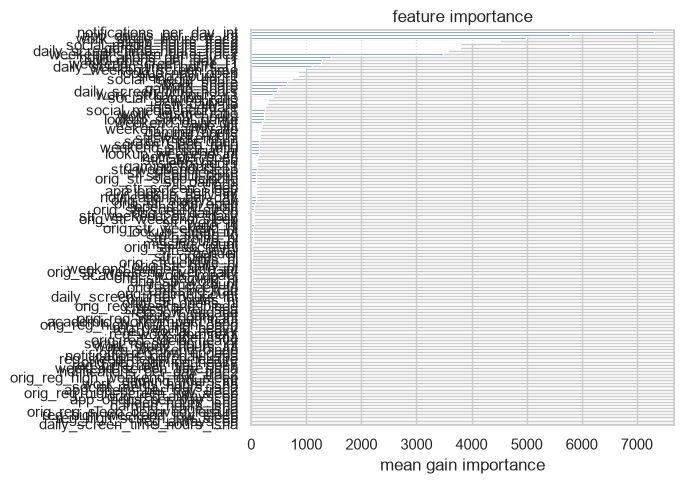

,importance
notifications_per_day_int,7309.577778
app_opens_per_day_int,5795.333333
work_study_hours_frac2,4993.600000
sleep_hours_frac2,4520.733333
social_media_hours_frac2,3798.555556
...,...
reg_high_weekend_low_sleep,0.000000
daily_screen_time_hours_isna,0.000000
reg_always_on,0.000000
orig_reg_sleep_deprived_leisure,0.000000


In [25]:
imp = importances.mean(axis=1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set(xlabel="mean gain importance", title="feature importance")
plt.tight_layout()
plt.show()

imp.sort_values(ascending=False).to_frame("importance")

## Submission

In [26]:
submission = sample_submission.copy()
submission[TARGET] = test_preds
submission.to_csv("submission.csv")
print(f"oof auc: {oof_score:.5f}")
submission.head()

oof auc: 0.96898


,addicted_label
id,
691369,0.999584
691370,0.971297
691371,0.816273
691372,0.995152
691373,0.997730
